# Correlation & Statistical Analysis

## Objective

The objective of this notebook is to quantify the relationship between cryptocurrency and traditional financial assets using statistical correlation techniques.

The analysis evaluates whether Bitcoin and Ethereum have become increasingly integrated with Gold and the S&P 500, thereby addressing the primary research question of this project.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

from pathlib import Path

plt.style.use("ggplot")

In [2]:
# Dark crypto theme
plt.style.use("dark_background")

crypto_palette = {
    "Bitcoin": "#F7931A",   # Orange
    "Ethereum": "#627EEA",  # Blue
    "Gold": "#FFD700",      # Gold
    "SP500": "#2ECC71"      # Green
}
sns.set_theme(
    style="darkgrid",
    context="talk",
)

In [3]:
PROCESSED_PATH = Path("crypto_project/data/processed")

market = pd.read_csv(
    PROCESSED_PATH / "market_data_features.csv"
)

market["Date"] = pd.to_datetime(market["Date"])

In [4]:
market.head()

,Date,Close,High,Low,Open,Volume,Asset,Daily_Return,Log_Return,Cumulative_Return,Rolling_Mean_30,Rolling_STD_30
0,2019-01-01,3843.520020,3850.913818,3707.231201,3746.713379,4324200990,Bitcoin,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,140.819412,141.397507,132.650711,133.418152,2258709868,Ethereum,NaN,NaN,NaN,NaN,NaN
2,2019-01-02,3943.409424,3947.981201,3817.409424,3849.216309,5244856836,Bitcoin,0.025989,0.025657,0.025989,NaN,NaN
3,2019-01-02,155.047684,156.929138,140.650955,141.519516,3328240369,Ethereum,0.101039,0.096254,0.101039,NaN,NaN
4,2019-01-02,121.330002,121.750000,120.879997,121.349998,12776200,Gold,NaN,NaN,NaN,NaN,NaN


## Reshaping Data for Correlation Analysis

To analyze the relationship between asset returns, the dataset is transformed from **long format** to **wide format** using a pivot table.

- **Rows:** Trading dates
- **Columns:** Assets (Bitcoin, Ethereum, Gold, S&P 500)
- **Values:** Daily Return

This structure is required for correlation analysis, heatmaps, and multivariate financial analysis.

In [5]:
returns = market.pivot(
    index="Date",
    columns="Asset",
    values="Daily_Return"
)

In [6]:
returns.head()

Asset,Bitcoin,Ethereum,Gold,SP500
Date,,,,
2019-01-01,NaN,NaN,NaN,NaN
2019-01-02,0.025989,0.101039,NaN,NaN
2019-01-03,-0.027050,-0.038135,0.009066,-0.024757
2019-01-04,0.005467,0.036523,-0.008086,0.034336
2019-01-05,-0.003246,0.006836,NaN,NaN


In [7]:
returns.isna().sum()

Asset
Bitcoin       1
Ethereum      1
Gold        683
SP500       683
dtype: int64

### Pearson Correlation Matrix

In [8]:
corr =returns.corr()

corr

Asset,Bitcoin,Ethereum,Gold,SP500
Asset,,,,
Bitcoin,1.000000,0.816933,0.154214,0.331733
Ethereum,0.816933,1.000000,0.147129,0.353393
Gold,0.154214,0.147129,1.000000,0.122985
SP500,0.331733,0.353393,0.122985,1.000000


### Interpretation

BTC–ETH shows the strongest positive relationship.

Gold has weak correlation with cryptocurrencies.

S&P 500 has moderate positive correlation with Bitcoin.

Assets do not behave identically.

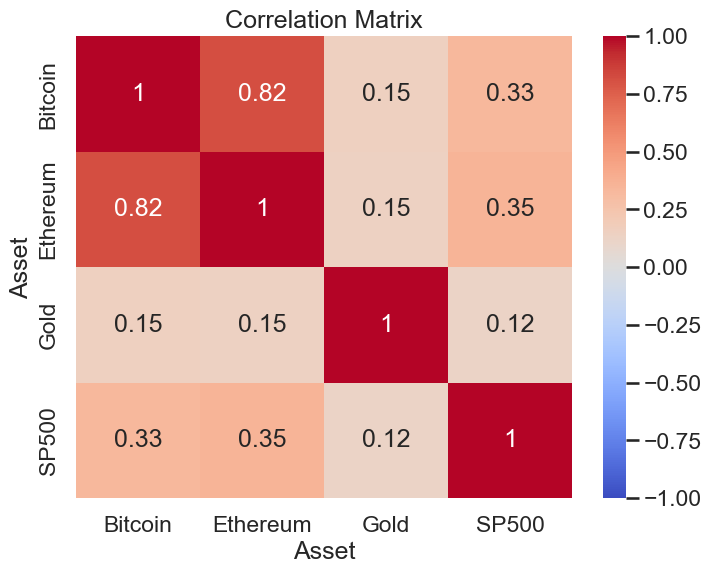

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Before & After Covid

In [10]:
pre_covid = returns[
    returns.index < "2020-03-01"
]

post_covid = returns[
    returns.index >= "2020-03-01"
]

pre_corr = pre_covid.corr()

post_corr = post_covid.corr()


In [11]:
pre_corr

Asset,Bitcoin,Ethereum,Gold,SP500
Asset,,,,
Bitcoin,1.000000,0.814651,0.159770,-0.031729
Ethereum,0.814651,1.000000,0.070036,0.049191
Gold,0.159770,0.070036,1.000000,-0.223148
SP500,-0.031729,0.049191,-0.223148,1.000000


In [12]:
post_corr

Asset,Bitcoin,Ethereum,Gold,SP500
Asset,,,,
Bitcoin,1.000000,0.817951,0.153764,0.388788
Ethereum,0.817951,1.000000,0.160481,0.398239
Gold,0.153764,0.160481,1.000000,0.164264
SP500,0.388788,0.398239,0.164264,1.000000


### Interpretation

* **Bitcoin and Ethereum** maintained a strong positive correlation both **before (0.81)** and **after COVID-19 (0.82)**, indicating that the two cryptocurrencies continued to move together.
* **Bitcoin and the S&P 500** shifted from **almost no correlation (-0.03)** before COVID-19 to a **moderate positive correlation (0.39)** after COVID-19, suggesting stronger co-movement in the post-pandemic period.
* **Ethereum and the S&P 500** also showed a notable increase in correlation, rising from **0.05** to **0.40**.
* **Gold** remained only **weakly correlated** with cryptocurrencies in both periods, reinforcing its role as a relatively independent asset.
* **Overall, the post-COVID period shows increased correlation between cryptocurrencies and traditional financial markets, while the strong relationship between Bitcoin and Ethereum remained largely unchanged.**


## Statistical Significance
### Bitcoin VS S&P500

In [13]:
btc = returns["Bitcoin"].dropna()

sp = returns["SP500"].dropna()

common = pd.concat(
    [btc,sp],
    axis=1
).dropna()

r,p = pearsonr(
    common.iloc[:,0],
    common.iloc[:,1]
)

print(r)

print(p)

0.33173274453964025
4.344664149389541e-40


### Interpretation

A moderate **positive correlation** exists between Bitcoin and the S&P 500 (r = 0.332).

The very small p-value (p < 0.001) indicates that this relationship is statistically significant and is **unlikely to have occurred by chance**.

### Bitcoin VS Gold

In [14]:
btc = returns["Bitcoin"].dropna()

gold = returns["Gold"].dropna()

common = pd.concat(
    [btc,gold],
    axis=1
).dropna()

r,p = pearsonr(
    common.iloc[:,0],
    common.iloc[:,1]
)

print(r)

print(p)

0.15421353695054846
1.726516378132534e-09


## Ethereum Vs S&P500

In [15]:
eth = returns["Ethereum"].dropna()

sp = returns["SP500"].dropna()

common = pd.concat(
    [eth,sp],
    axis=1
).dropna()

r,p = pearsonr(
    common.iloc[:,0],
    common.iloc[:,1]
)

print(r)

print(p)

0.3533934053540627
1.282103058647622e-45


## Ethereum VS Gold

In [16]:
eth = returns["Ethereum"].dropna()

sp = returns["SP500"].dropna()

common = pd.concat(
    [eth,sp],
    axis=1
).dropna()

r,p = pearsonr(
    common.iloc[:,0],
    common.iloc[:,1]
)

print(r)

print(p)

0.3533934053540627
1.282103058647622e-45


### Statistical Significance of Correlations

| Asset Pair         | Correlation (r) | p-value | Interpretation                                            |
| ------------------ | :-------------: | :-----: | --------------------------------------------------------- |
| Bitcoin – S&P 500  |      0.332      | < 0.001 | Moderate positive correlation; statistically significant. |
| Bitcoin – Gold     |      0.154      | < 0.001 | Weak positive correlation; statistically significant.     |
| Ethereum – S&P 500 |      0.353      | < 0.001 | Moderate positive correlation; statistically significant. |
| Ethereum – Gold    |      0.353      | < 0.001 | Moderate positive correlation; statistically significant. |

**Overall Insight:** All asset pairs exhibit **statistically significant positive correlations** (p < 0.001). However, the **strength of the relationships varies**, with cryptocurrencies showing a stronger association with the S&P 500 than with Gold.


## Research Hypotheses
*  **Hypothesis 1 (H1):** Market Decoupling

    * Null Hypothesis (H₀₁):
        
        There is no significant change in the relationship between cryptocurrencies (Bitcoin and Ethereum) and traditional financial assets (Gold and the S&P 500) during the study period (2019–2024).

    * Alternative Hypothesis (H₁₁):

        The relationship between cryptocurrencies and traditional financial assets has changed significantly over time, indicating either increasing integration or decoupling.

Tested Using
Pearson Correlation, 
Rolling 90-Day Correlation, 
Correlation Heatmaps, 
Pre-COVID vs Post-COVID Correlation, 
Pearson Significance Test (p-value)

## Hypothesis Evaluation

| Hypothesis                     |    Status    | Evidence                                                                                                                                                                                             |
| ------------------------------ | :----------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **H1: Market Decoupling**      | **Rejected** | Correlation analysis, pre- vs post-COVID comparison, and Pearson significance tests indicate increased correlation between cryptocurrencies and traditional financial assets after 2020 (p < 0.001). |
| **H2: Risk Characteristics**   |  **Pending** | To be evaluated using annualized volatility, rolling volatility, maximum drawdown, and recovery time in **Notebook 06**.                                                                             |
| **H3: Investment Performance** |  **Pending** | To be evaluated using cumulative returns, CAGR, Sharpe ratio, and annual returns in **Notebook 06**.                                                                                                 |

### Conclusion

The results from Notebook 05 suggest that cryptocurrencies, particularly Bitcoin and Ethereum, became more integrated with traditional financial markets after 2020. Therefore, the hypothesis that there is **no significant change** in the relationship between cryptocurrencies and traditional assets is **rejected**.


### Next Notebook

06_risk_and_performance_analysis.ipynb